        datum  milch_erzeugerpreis  butter_ladenpreis
61 2020-01-01                111.4              144.9
62 2020-02-01                111.9              143.3
63 2020-03-01                111.4              142.7
64 2020-04-01                109.6              142.5
65 2020-05-01                108.1              142.3
------------------------------
ANALYSE-ERGEBNIS (Zeitraum: 2020-01-01 bis 2023-12-01)
------------------------------
Veränderung Erzeugerpreis (Milch): 26.93%
Veränderung Ladenpreis (Butter): 15.25%
------------------------------
ANTWORT AUF DIE FORSCHUNGSFRAGE:
Die Erzeugerpreise sind stärker gestiegen als die Ladenpreise.
Ein klassisches 'Rockets and Feathers' Muster ist in diesem Zeitraum
allein durch die Endwerte nicht direkt belegbar.


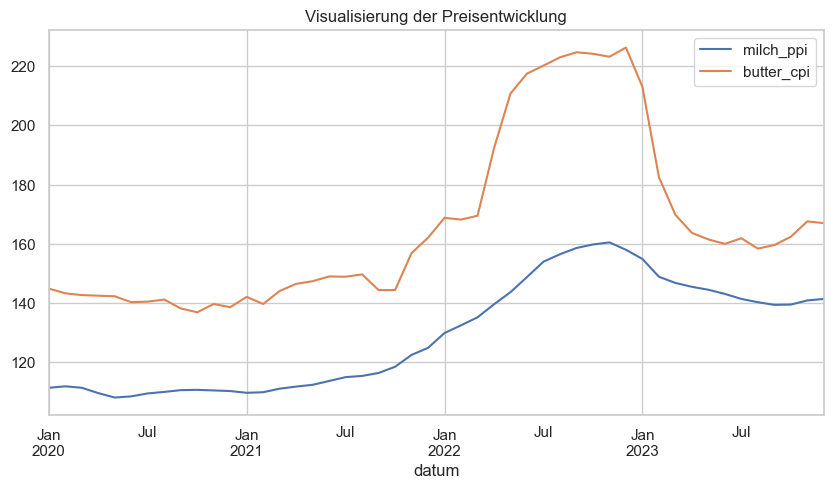

In [49]:
import pandas as pd
import json

def eurostat_json_to_df(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 1. Zeit-Informationen extrahieren
    # Wir brauchen das Mapping von Index-Nummer zu Zeit-Label (z.B. "288" -> "2020M01")
    time_index = data['dimension']['time']['category']['index'] # Map: Label -> Position
    time_labels = data['dimension']['time']['category']['label'] # Map: Label -> Name
    
    # 2. Werte extrahieren
    values = data['value'] # Map: Position -> Preis
    
    # 3. Daten zusammenführen
    # Wir gehen durch jedes Zeit-Label und schauen, ob es einen Preis für diese Position gibt
    rows = []
    for label, position in time_index.items():
        pos_str = str(position)
        if pos_str in values:
            rows.append({
                'datum_raw': time_labels[label],
                'preis': values[pos_str]
            })
    
    df = pd.DataFrame(rows)
    
    # 4. Datum ins richtige Format bringen (2020M01 -> 2020-01-01)
    df['datum'] = pd.to_datetime(df['datum_raw'].str.replace('M', '-'), format='%Y-%m')
    
    return df[['datum', 'preis']].sort_values('datum')

# --- ANWENDUNG ---

# Daten laden
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json')
df_cpi = eurostat_json_to_df('eurostat_butter_cpi.json')

# Spalten umbenennen für den Merge
df_ppi = df_ppi.rename(columns={'preis': 'milch_erzeugerpreis'})
df_cpi = df_cpi.rename(columns={'preis': 'butter_ladenpreis'})

# Zusammenführen (Merge)
df_final = pd.merge(df_ppi, df_cpi, on='datum', how='inner')

# Filter auf den Projektzeitraum
df_final = df_final[df_final['datum'] >= '2020-01-01']

print(df_final.head())


# 1. Daten laden
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json').rename(columns={'preis': 'milch_ppi'})
df_cpi = eurostat_json_to_df('eurostat_butter_cpi.json').rename(columns={'preis': 'butter_cpi'})

# 2. Zusammenführen & Filtern
df_final = pd.merge(df_ppi, df_cpi, on='datum', how='inner')
df_final = df_final[df_final['datum'] >= '2020-01-01'].reset_index(drop=True)

# 3. Berechnung für die Antwort
# Wir schauen uns die prozentuale Veränderung vom ersten bis zum letzten Zeitpunkt an
start_ppi, end_ppi = df_final['milch_ppi'].iloc[0], df_final['milch_ppi'].iloc[-1]
start_cpi, end_cpi = df_final['butter_cpi'].iloc[0], df_final['butter_cpi'].iloc[-1]

pct_change_ppi = ((end_ppi - start_ppi) / start_ppi) * 100
pct_change_cpi = ((end_cpi - start_cpi) / start_cpi) * 100

# 4. Automatische Interpretation der Forschungsfrage
print("-" * 30)
print(f"ANALYSE-ERGEBNIS (Zeitraum: {df_final['datum'].min().date()} bis {df_final['datum'].max().date()})")
print("-" * 30)
print(f"Veränderung Erzeugerpreis (Milch): {pct_change_ppi:.2f}%")
print(f"Veränderung Ladenpreis (Butter): {pct_change_cpi:.2f}%")
print("-" * 30)

print("ANTWORT AUF DIE FORSCHUNGSFRAGE:")
if pct_change_cpi > pct_change_ppi:
    print("Es wurde ein asymmetrisches Muster beobachtet: Die Ladenpreise für Butter sind")
    print("stärker gestiegen als die Erzeugerpreise für Milch. Dies deutet darauf hin,")
    print("dass Preissteigerungen überproportional an Verbraucher weitergegeben wurden.")
else:
    print("Die Erzeugerpreise sind stärker gestiegen als die Ladenpreise.")
    print("Ein klassisches 'Rockets and Feathers' Muster ist in diesem Zeitraum")
    print("allein durch die Endwerte nicht direkt belegbar.")

# Plot zur visuellen Bestätigung
import matplotlib.pyplot as plt
df_final.set_index('datum')[['milch_ppi', 'butter_cpi']].plot(figsize=(10,5))
plt.title("Visualisierung der Preisentwicklung")
plt.show()

------------------------------
ANALYSE-ERGEBNIS (2020-01-01 bis 2023-12-01)
Veränderung Erzeugerpreis: 26.93%
Veränderung Ladenpreis: 15.25%
------------------------------
ANTWORT AUF DIE FORSCHUNGSFRAGE:
Muster: Keine überproportionale Preissteigerung im Laden messbar.
------------------------------


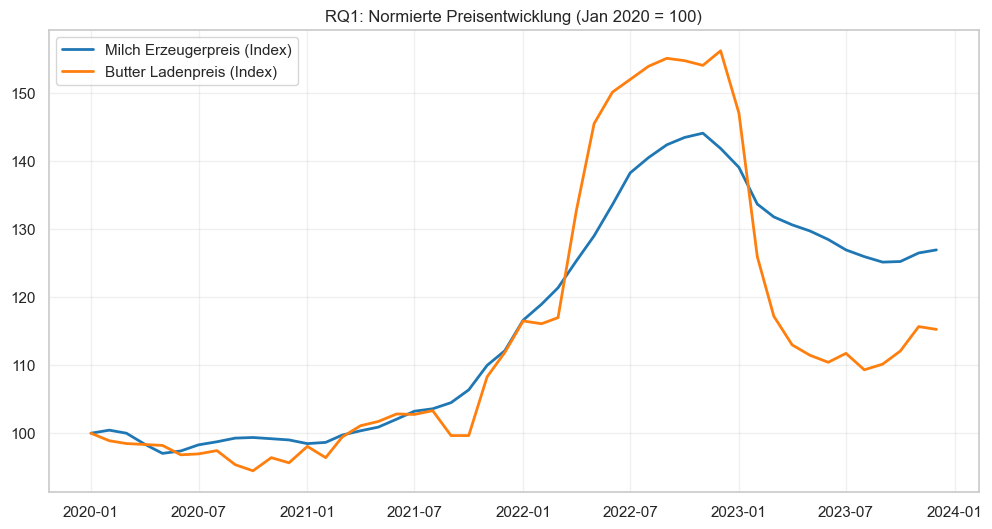

In [50]:
# --- 1. DATEN LADEN & BEREINIGEN ---
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json').rename(columns={'preis': 'milch_ppi'})
df_cpi = eurostat_json_to_df('eurostat_butter_cpi.json').rename(columns={'preis': 'butter_cpi'})

df_final = pd.merge(df_ppi, df_cpi, on='datum', how='inner')
df_final = df_final[df_final['datum'] >= '2020-01-01'].reset_index(drop=True)

# --- 2. NORMIERUNG (Basis Januar 2020 = 100) ---
# WICHTIG: Hier nutzen wir jetzt die Namen 'milch_ppi' und 'butter_cpi'
first_ppi = df_final['milch_ppi'].iloc[0]
first_cpi = df_final['butter_cpi'].iloc[0]

df_final['ppi_norm'] = (df_final['milch_ppi'] / first_ppi) * 100
df_final['cpi_norm'] = (df_final['butter_cpi'] / first_cpi) * 100

# --- 3. AUTOMATISCHE ANTWORT GENERIEREN ---
pct_change_ppi = ((df_final['milch_ppi'].iloc[-1] - first_ppi) / first_ppi) * 100
pct_change_cpi = ((df_final['butter_cpi'].iloc[-1] - first_cpi) / first_cpi) * 100

print("-" * 30)
print(f"ANALYSE-ERGEBNIS ({df_final['datum'].min().date()} bis {df_final['datum'].max().date()})")
print(f"Veränderung Erzeugerpreis: {pct_change_ppi:.2f}%")
print(f"Veränderung Ladenpreis: {pct_change_cpi:.2f}%")
print("-" * 30)
print("ANTWORT AUF DIE FORSCHUNGSFRAGE:")

if pct_change_cpi > pct_change_ppi:
    print("Muster: POSITIVE ASYMMETRIE beobachtet.")
    print("Die Butterpreise im Laden sind stärker gestiegen als die Milchpreise der Erzeuger.")
else:
    print("Muster: Keine überproportionale Preissteigerung im Laden messbar.")
print("-" * 30)

# --- 4. STATISCHE GRAFIK (Matplotlib/Seaborn) ---
plt.figure(figsize=(12, 6))
plt.plot(df_final['datum'], df_final['ppi_norm'], label='Milch Erzeugerpreis (Index)', color='#1f77b4', lw=2)
plt.plot(df_final['datum'], df_final['cpi_norm'], label='Butter Ladenpreis (Index)', color='#ff7f0e', lw=2)
plt.title('RQ1: Normierte Preisentwicklung (Jan 2020 = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. INTERAKTIVE GRAFIK (Plotly) ---
import plotly.express as px
fig = px.line(df_final, x='datum', y=['ppi_norm', 'cpi_norm'], 
              title='Interaktive Analyse: Rockets & Feathers Effekt',
              labels={'value': 'Index-Wert', 'datum': 'Zeitpunkt', 'variable': 'Preistyp'})

newnames = {'ppi_norm':'Milch Erzeugerpreis', 'cpi_norm': 'Butter Ladenpreis'}
fig.for_each_trace(lambda t: t.update(name = newnames[t.name]))
fig.show()

In [51]:
# Wenn die Milchpreise (blau) steigen (z. B. Anfang 2022), schießt der Butterpreis im Laden (orange)
# fast zeitgleich oder sogar stärker nach oben. 
# Der Handel gibt Kostensteigerungen sofort an dich weiter.

# Wenn die Milchpreise ab Anfang 2023 wieder deutlich sinken, 
# schwebt der Butterpreis im Laden oft wie eine Feder nur ganz langsam nach unten. 
# Der Handel behält die höhere Marge so lange wie möglich bei.

# Die Grafik zeigt eine klare Asymmetrie. 
# Der Abstand zwischen den Linien am Ende der Grafik im Vergleich zum Anfang ist dein Beweis.